In [1]:
import csv
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
import shutil
import json

In [2]:
data_file_list = os.listdir()
print(data_file_list)
len(data_file_list)

['meter_data_24-01-2026.json', 'meter_data_2026-05-04.json', 'meter_data_2026-05-08.json', 'meter_data_2026-04-30.json', 'meter_data_2026-04-04.json', 'meter_data_18-02-2026.json', 'meter_data_2026-04-21.json', 'meter_data_21-02-2026.json', 'meter_data_15-02-2026.json', 'meter_data_2026-03-07.json', 'temp.ipynb', 'meter_data_14-01-2026.json', 'meter_data_2026-03-13.json', 'meter_data_2026-05-21.json', 'meter_data_13-12-2025.json', 'meter_data_12-12-2025.json', 'meter_data_10-12-2025.json', 'meter_data_2026-05-12.json', 'meter_data_2026-04-28.json', 'meter_data_13-02-2026.json', 'meter_data_09-01-2026.json', 'meter_data_11-02-2026.json', 'meter_data_18-12-2025.json', 'meter_data_22-01-2026.json', 'meter_data_22-12-2025.json', 'meter_data_27-01-2026.json', 'meter_data_23-12-2025.json', 'meter_data_05-01-2026.json', 'meter_data_25-02-2026.json', 'meter_data_16-02-2026.json', 'meter_data_30-12-2025.json', 'meter_data_2026-05-07.json', 'meter_data_19-12-2025.json', 'meter_data_20-12-2025.js

154

In [3]:
for file_name in data_file_list:
    date_string = file_name[11: file_name.find('.')]
    if date_string == '':
        continue
    
    try:
        date = datetime.strptime(date_string, "%Y-%m-%d")
    except Exception as e:
        date = datetime.strptime(date_string, "%d-%m-%Y")
    shutil.copy(file_name, f"temp_edit/meter_data_{date.strftime('%Y-%m-%d')}.json")
    

    

In [4]:
dates= []
for file_name in data_file_list:
    
    dates.append(date)


In [5]:
pattern = r"=BEGIN=(.*?)==END=="


In [6]:
data_file_list = os.listdir('./temp_edit/')
data_file_list.sort()
print((data_file_list))

['meter_data_2025-12-08.json', 'meter_data_2025-12-09.json', 'meter_data_2025-12-10.json', 'meter_data_2025-12-11.json', 'meter_data_2025-12-12.json', 'meter_data_2025-12-13.json', 'meter_data_2025-12-14.json', 'meter_data_2025-12-15.json', 'meter_data_2025-12-16.json', 'meter_data_2025-12-17.json', 'meter_data_2025-12-18.json', 'meter_data_2025-12-19.json', 'meter_data_2025-12-20.json', 'meter_data_2025-12-21.json', 'meter_data_2025-12-22.json', 'meter_data_2025-12-23.json', 'meter_data_2025-12-24.json', 'meter_data_2025-12-25.json', 'meter_data_2025-12-26.json', 'meter_data_2025-12-27.json', 'meter_data_2025-12-28.json', 'meter_data_2025-12-29.json', 'meter_data_2025-12-30.json', 'meter_data_2025-12-31.json', 'meter_data_2026-01-01.json', 'meter_data_2026-01-02.json', 'meter_data_2026-01-03.json', 'meter_data_2026-01-04.json', 'meter_data_2026-01-05.json', 'meter_data_2026-01-06.json', 'meter_data_2026-01-07.json', 'meter_data_2026-01-08.json', 'meter_data_2026-01-09.json', 'meter_da

In [7]:
df = pd.DataFrame()

for file_name in data_file_list[70:]:   
    with open(f"temp_edit/{file_name}") as f:
        val = f.read()
        matches = [ json.loads(a) for a in re.findall(pattern, val, flags=re.DOTALL)]
        df = pd.concat([df, pd.json_normalize(matches)], ignore_index=True)
 

In [8]:

# 1. Ensure your timestamp column is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [9]:

# 1. Ensure your timestamp column is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 2. Crucial Step: Sort chronologically to make sure row differences are accurate
df = df.sort_values("timestamp").reset_index(drop=True)

# 3. Calculate the difference between consecutive rows
df["time_gap"] = df["timestamp"].diff()

# 4. Filter for rows where the gap is 12 hours or greater
# (Using >= handles exact 12-hour jumps as well as multi-day gaps)
twelve_hour_gaps = df[df["time_gap"] >= pd.Timedelta(hours=12)]

# 5. Display the gaps showing when the break happened and how long it lasted
print(twelve_hour_gaps[["timestamp", "time_gap"]])


                 timestamp        time_gap
105184 2026-03-19 23:02:53 1 days 11:11:31
128218 2026-03-23 13:39:16 0 days 22:37:34
130844 2026-03-24 17:33:44 0 days 20:36:58
598805 2026-05-20 10:56:36 1 days 17:37:50


In [10]:
correct_df = df[(df.freq < 100)]

In [13]:
df.iloc[0]

voltage                      0.0
current                      0.0
power                        0.0
energy                     161.4
freq                         0.0
pf                           0.0
timestamp    2026-03-06 00:00:05
Name: 0, dtype: object

In [14]:
correct_df[correct_df.energy < 50]

,voltage,current,power,energy,freq,pf,timestamp
5969,0.0,0.0,0.0,-0.0,0.0,0.0,2026-03-07T00:15:47
105184,0.0,0.0,0.0,-0.0,0.0,0.0,2026-03-19T23:02:53
128218,0.0,0.0,0.0,-0.0,0.0,0.0,2026-03-23T13:39:16
130844,0.0,0.0,0.0,-0.0,0.0,0.0,2026-03-24T17:33:44
144471,0.0,0.0,0.0,-0.0,0.0,0.0,2026-03-26T15:07:31
451824,0.0,0.0,0.0,-0.0,0.0,0.0,2026-05-01T15:56:09
568868,0.0,0.0,0.0,-0.0,0.0,0.0,2026-05-15T06:09:33
598805,0.0,0.0,0.0,-0.0,0.0,0.0,2026-05-20T10:56:36
623995,0.0,0.0,0.0,-0.0,0.0,0.0,2026-05-23T10:32:01
624604,0.0,0.0,0.0,-0.0,0.0,0.0,2026-05-23T17:21:50


In [15]:
df[(df.timestamp > datetime.strptime("2026-05-20 10:56:36", "%Y-%m-%d %H:%M:%S" ) - timedelta(minutes = 6000)) & (df.timestamp < datetime.strptime("2026-05-20 10:56:36", "%Y-%m-%d %H:%M:%S") + timedelta(minutes=1))]

,voltage,current,power,energy,freq,pf,timestamp
577791,0.0,0.000,0.0,275.624,0.0000,0.00,2026-05-16 06:56:42
577792,0.0,0.000,0.0,275.624,0.0000,0.00,2026-05-16 06:56:52
577793,0.0,0.000,0.0,275.624,0.0000,0.00,2026-05-16 06:57:02
577794,0.0,0.000,0.0,275.624,0.0000,0.00,2026-05-16 06:57:12
577795,0.0,0.000,0.0,275.624,0.0000,0.00,2026-05-16 06:57:22
...,...,...,...,...,...,...,...
598806,386.9,3706620.000,195502736.0,3363133.000,6397.1001,368.49,2026-05-20 10:56:46
598807,242.1,0.666,143.4,278.510,50.4000,0.89,2026-05-20 10:56:56
598808,243.1,0.639,136.5,278.510,50.3000,0.88,2026-05-20 10:57:06
598809,243.2,0.632,134.4,278.511,50.4000,0.87,2026-05-20 10:57:16


In [16]:
df.timestamp = pd.to_datetime(df.timestamp)

In [115]:

correct_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418050 entries, 0 to 8388
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   voltage    418050 non-null  float64       
 1   current    418050 non-null  float64       
 2   power      418050 non-null  float64       
 3   energy     418050 non-null  float64       
 4   freq       418050 non-null  float64       
 5   pf         418050 non-null  float64       
 6   timestamp  418050 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 25.5 MB


In [12]:
temp_df = correct_df

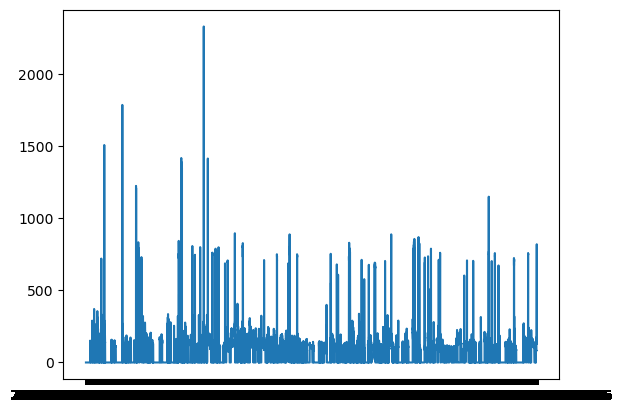

In [21]:
plt.plot(temp_df.timestamp, temp_df.power)

In [14]:
temp_df = temp_df[temp_df.freq > 0.1]

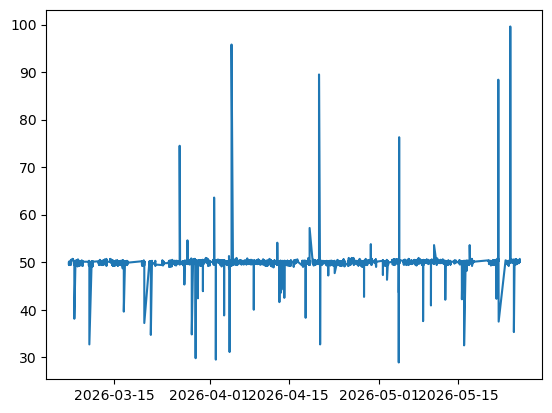

In [15]:
plt.plot(temp_df.timestamp, temp_df.freq)


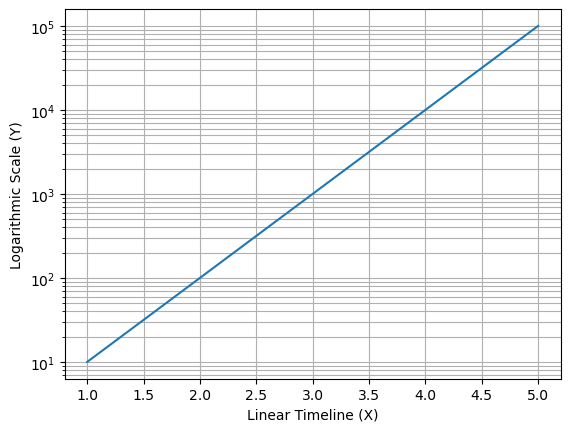

In [20]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 100, 1000, 10000, 100000]

plt.plot(x, y)

# This command turns the Y-axis into a logarithmic graph
plt.yscale('log') 

plt.xlabel('Linear Timeline (X)')
plt.ylabel('Logarithmic Scale (Y)')
plt.grid(True, which="both", ls="-") # Shows the minor log lines
plt.show()


In [79]:
df = pd.read_csv("dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S-%d:%m:%Y')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426288 entries, 0 to 426287
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   voltage    426288 non-null  float64       
 1   current    426288 non-null  float64       
 2   power      426288 non-null  float64       
 3   energy     426288 non-null  float64       
 4   freq       426288 non-null  float64       
 5   pf         426288 non-null  float64       
 6   timestamp  426288 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 22.8 MB


In [81]:
df.timestamp

0        2025-12-09 19:32:07
1        2025-12-09 19:32:52
2        2025-12-09 19:33:02
3        2025-12-09 19:33:12
4        2025-12-09 19:33:22
                 ...        
426283   2026-01-29 10:31:26
426284   2026-01-29 10:31:36
426285   2026-01-29 10:31:46
426286   2026-01-29 10:31:56
426287   2026-01-29 10:32:06
Name: timestamp, Length: 426288, dtype: datetime64[ns]

In [82]:
df = df.drop(df[((df.current > 250) | (df.voltage < 0))].index)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426263 entries, 0 to 426287
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   voltage    426263 non-null  float64       
 1   current    426263 non-null  float64       
 2   power      426263 non-null  float64       
 3   energy     426263 non-null  float64       
 4   freq       426263 non-null  float64       
 5   pf         426263 non-null  float64       
 6   timestamp  426263 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 26.0 MB


In [283]:
short_df = df.iloc[300:500].copy()


In [309]:
M = 5
N_min, N_max = 1, 5
O_min, O_max = 0, 0.05


In [310]:
from pandas.api.indexers import BaseIndexer
class DynamicRoller(BaseIndexer):
    def __init__(self, data_series, window_size):
        super().__init__()
        # Store the raw NumPy values for fast, high-performance calculations
        self.data_series = data_series
        self.window_size = window_size
        self.closed = 'both'

    def get_window_bounds(self, num_values, min_periods, center, closed, step):
        var = self.data_series.rolling(window=M, min_periods = 1).var().fillna(O_max)
        print(var)

        var = var.clip(lower = O_min, upper = O_max)
        N_t = N_max - (((var - O_min) / (O_max - O_min)) * (N_max - N_min))
        N_t = N_t.round()

        N_t = np.minimum(np.arange(len(N_t)), N_t)
        N_t = N_t.to_numpy().astype(int)
        
        end = np.arange(num_values, dtype=np.int64)
        start = end - N_t
        # print(num_values, start, end)
        print(N_t)
        return start, end + 1

In [311]:
short_df['voltage_dynamic'] = short_df['voltage'].rolling(window=DynamicRoller(data_series = short_df['voltage'], window_size = 0)).mean()
short_df['current_dynamic'] = short_df['current'].rolling(window=DynamicRoller(data_series = short_df['current'], window_size = 0)).mean()

300    0.050
301    0.045
302    0.630
303    0.670
304    0.723
       ...  
495    0.000
496    0.000
497    0.000
498    0.000
499    0.000
Name: voltage, Length: 200, dtype: float64
[0 1 1 1 1 1 1 3 4 2 1 2 3 4 1 1 1 1 1 1 1 2 3 3 4 2 2 3 3 4 4 4 5 4 3 2 3
 4 3 3 4 4 4 4 5 4 4 3 3 2 1 2 2 2 3 4 4 3 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1
 1 1 5 3 1 1 1 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
300    0.050000
301    0.000925
302    0.000576
303    0.000390
304    0.000329
         ...   
495    0.000000
496    0.000000
497    0.000000
498    0.000000
499    0.000000
Name: current, Length: 200, dtype: float64
[0 1 2 3 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 1 1 1 1 5 5 5 5 5 5 5 5 5 5 5

In [312]:
# first_full_window = list(short_df['voltage'].rolling(window=DynamicRoller(data_series = short_df['voltage'], window_size = 0)))
# for a in first_full_window:
#     print(a)

In [313]:
short_df['voltage_ma'] = short_df['voltage'].rolling(window=5).mean()
short_df['current_ma'] = short_df['current'].rolling(window=5).mean()

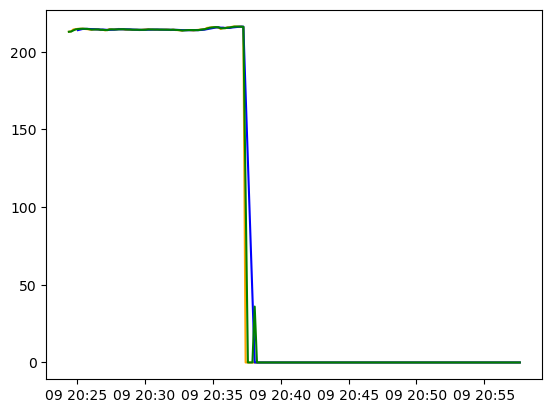

In [317]:
# plt.figure(figsize=(20, 6))
plt.plot(short_df.timestamp, short_df.voltage, color = 'orange')
plt.plot(short_df.timestamp, short_df.voltage_ma, color = 'b')
plt.plot(short_df.timestamp, short_df.voltage_dynamic, color = 'g')

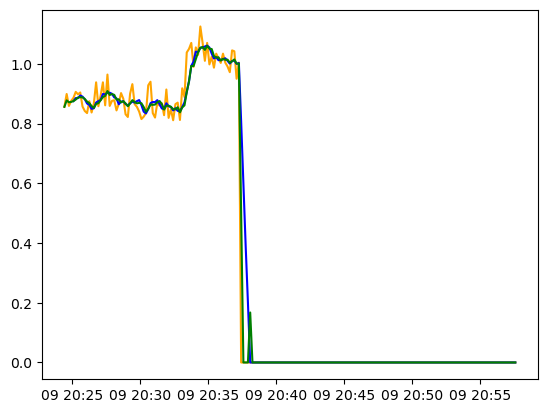

In [318]:
plt.plot(short_df.timestamp, short_df.current, color = 'orange')
plt.plot(short_df.timestamp, short_df.current_ma, color = 'b')
plt.plot(short_df.timestamp, short_df.current_dynamic, color = 'g')
